# Student Depression — Model-Building Process

This notebook follows the standard model-building flowchart:

1. **Fit the full model**
2. **Drop uninformative columns** (pre-screening)
3. **Fit the reduced model**
4. **Residual analysis**
5. **Transformation?** (if yes, transform and loop back)
6. **All possible regressions** (stepwise selection)
7. **Select models for further analysis**
8. **Make recommendations**

---

## Setup — imports and load data


In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy import stats as sp_stats
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (r2_score, classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

path = r"path"
df = pd.read_csv(path)

## Data preparation

Before fitting, we need to do the minimum cleaning required to get a well-defined
design matrix: handle missing values, restrict to the population of interest
(students), drop columns that are definitionally inapplicable (`Work Pressure`,
`Job Satisfaction` — these only apply to workers), and collapse rare levels of
`City` so one-hot encoding doesn't explode.

**Note:** We are NOT dropping `Gender` or anything else based on statistical tests
yet. That belongs in the model-selection stage, *after* we've fit and diagnosed
the full model.

In [90]:
df.isna().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [91]:
# Restrict to students and drop columns that only apply to workers
df = df[df['Profession'] == 'Student']
df = df.drop(columns=['Profession', 'Work Pressure', 'Job Satisfaction'])

# Drop the 3 rows with missing Financial Stress
df = df.dropna(subset=['Financial Stress'])

# Collapse rare cities into 'Other' so one-hot encoding stays manageable
city_counts = df['City'].value_counts()
cities_to_group = city_counts[city_counts < 100].index
df['City'] = df['City'].replace(cities_to_group, 'Other')

df.head()

,id,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [92]:
# One-hot encode categoricals, then split
df_encoded = pd.get_dummies(df, drop_first=True)

lr_X = df_encoded.drop(columns=['Depression'])
lr_y = df_encoded['Depression'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    lr_X, lr_y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep feature names on the scaled arrays
feature_names = lr_X.columns.tolist()
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names).astype(float).reset_index(drop=True)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names).astype(float).reset_index(drop=True)
y_train_sm = y_train.astype(float).reset_index(drop=True)
y_test_sm  = y_test.reset_index(drop=True)

print(f"Training set: {X_train_df.shape}")
print(f"Test set:     {X_test_df.shape}")
print(f"Features:     {len(feature_names)}")

Training set: (22293, 74)
Test set:     (5574, 74)
Features:     74


---
## Step 1 — Fit the full model

We fit the full logistic regression using `statsmodels` (unregularized) so we get
proper inference (standard errors, p-values, log-likelihood) and so this same
object can be reused for residual analysis and the later likelihood-ratio test.

In [93]:
X_full_train = sm.add_constant(X_train_df[feature_names])
full_model_sm = sm.Logit(y_train_sm, X_full_train).fit(disp=False, maxiter=200)

print("=" * 70)
print("FULL MODEL")
print("=" * 70)
print(full_model_sm.summary())

FULL MODEL
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                22293
Model:                          Logit   Df Residuals:                    22218
Method:                           MLE   Df Model:                           74
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.4926
Time:                        19:51:26   Log-Likelihood:                -7687.9
converged:                       True   LL-Null:                       -15151.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.5770      0.021     27.473      0.000       0.536       0.618
id                         

---
## Step 2 — Drop uninformative columns (pre-screening)

Before doing residual analysis and variable selection, we prune predictors that
are clearly uninformative based on exploratory plots and a simple association
test. `Gender` is the obvious candidate to check, and we also revisit `City`.


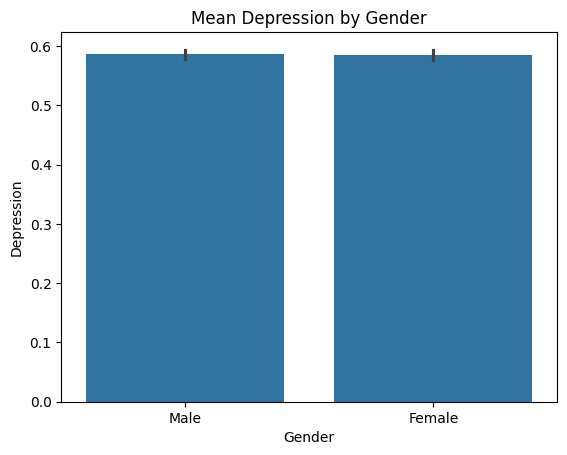

In [94]:
sns.barplot(data=df, x='Gender', y='Depression')
plt.title('Mean Depression by Gender')
plt.show()

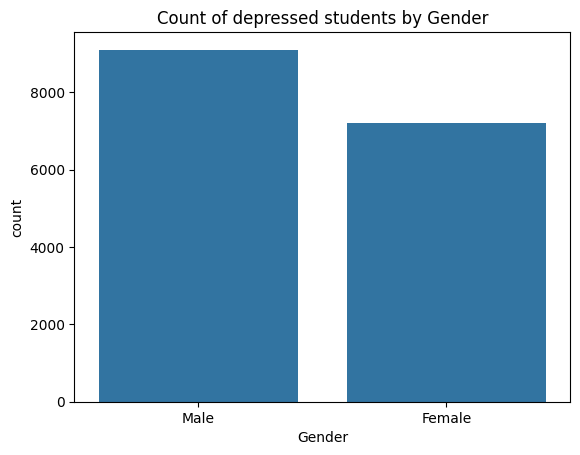

In [95]:
depressed_students = df[df['Depression'] == 1]
sns.countplot(data=depressed_students, x='Gender')
plt.title('Count of depressed students by Gender')
plt.show()

There are more depressed males in absolute terms, but the *proportions* look
similar across genders. We run a chi-square test to confirm.

In [96]:
contingency_table = pd.crosstab(df['Gender'], df['Depression'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"p-value:              {p_value:.4f}")

Chi-Square Statistic: 0.1004
p-value:              0.7514


Since p-value > 0.05 we fail to reject H0: `Gender` is not statistically
associated with `Depression`. We drop `Gender`. We also drop `City` because
even after grouping rare cities, it contributes many dummies with small effects
and is not a plausible scientific predictor of individual depression.

---
## Step 3 — Fit the reduced model

Drop `Gender` and `City` from the original dataframe, re-encode, re-split, and
re-scale with the same `random_state` so results are comparable. Then fit the
reduced logistic regression. This is the model we carry into residual analysis.


In [97]:
# Drop Gender and City from the *original* dataframe, then re-encode/split/scale.
# We keep the same random_state so results are reproducible and comparable.
df2 = df.drop(columns=['Gender', 'City', 'CGPA'])
df2_encoded = pd.get_dummies(df2, drop_first=True)

lr_X = df2_encoded.drop(columns=['Depression'])
lr_y = df2_encoded['Depression'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    lr_X, lr_y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

best_features = lr_X.columns.tolist()
X_train_df2 = pd.DataFrame(X_train_scaled, columns=best_features).astype(float).reset_index(drop=True)
X_test_df2  = pd.DataFrame(X_test_scaled,  columns=best_features).astype(float).reset_index(drop=True)
y_train_sm2 = y_train.astype(float).reset_index(drop=True)
y_test_sm2  = y_test.reset_index(drop=True)

# Refit the full model on the pruned feature set — this is our new "full" model
# for the selection stage.
X_full_train2 = sm.add_constant(X_train_df2[best_features])
reduced_model_sm = sm.Logit(y_train_sm2, X_full_train2).fit(disp=False, maxiter=200)

print(f"Pruned full model: {len(best_features)} predictors")
print(f"Log-likelihood:    {reduced_model_sm.llf:.2f}")
print(f"AIC:               {reduced_model_sm.aic:.2f}")

Pruned full model: 42 predictors
Log-likelihood:    -7730.77
AIC:               15547.55


In [98]:
X_full_train2 = sm.add_constant(X_train_df2[best_features])
reduced_model_sm = sm.Logit(y_train_sm2, X_full_train2).fit(disp=False, maxiter=200)

print("=" * 70)
print("REDUCED MODEL")
print("=" * 70)
print(reduced_model_sm.summary())

REDUCED MODEL
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                22293
Model:                          Logit   Df Residuals:                    22250
Method:                           MLE   Df Model:                           42
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.4897
Time:                        19:51:26   Log-Likelihood:                -7730.8
converged:                       True   LL-Null:                       -15151.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.5740      0.021     27.441      0.000       0.533       0.615
id                      

In [99]:
# ---- Side-by-side fit comparison ----
def test_accuracy(model, X_test_subset):
    probs = model.predict(sm.add_constant(X_test_subset))
    return accuracy_score(y_test_sm, (probs >= 0.5).astype(int))

comparison = pd.DataFrame({
    "Model"        : ["Full", "Reduced"],
    "# Predictors" : [len(feature_names), len(best_features)],
    "Log-Likelihood": [full_model_sm.llf, reduced_model_sm.llf],
    "AIC"          : [full_model_sm.aic, reduced_model_sm.aic],
    "BIC"          : [full_model_sm.bic, reduced_model_sm.bic],
    "Pseudo R²"    : [full_model_sm.prsquared, reduced_model_sm.prsquared],
    "Test Accuracy": [test_accuracy(full_model_sm, X_test_df[feature_names]),
                      test_accuracy(reduced_model_sm, X_test_df2[best_features])],
})
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison.to_string(index=False))


MODEL COMPARISON SUMMARY
  Model  # Predictors  Log-Likelihood          AIC          BIC  Pseudo R²  Test Accuracy
   Full            74    -7687.920306 15525.840611 16126.742712   0.492570       0.848583
Reduced            42    -7730.774929 15547.549858 15892.067062   0.489741       0.847327


---
## Step 4 — Residual analysis

Three checks for a logistic model, now performed on the **reduced model**:

1. **Pearson residuals vs. fitted probabilities** — should be centered around 0
   with roughly constant spread; systematic patterns suggest model misspecification.
2. **Calibration plot** — predicted probabilities should match observed frequencies
   along the diagonal.
3. **Influence / leverage** — a few high-leverage points can distort the fit.


In [100]:
# Fitted probabilities on the training set (from the reduced statsmodels model)
y_prob_train = reduced_model_sm.predict(X_full_train2)

# Pearson residuals (the logistic analog of OLS residuals)
pearson_residuals = (y_train_sm2 - y_prob_train) / np.sqrt(y_prob_train * (1 - y_prob_train))

# Test-set fitted probabilities for calibration
X_red_test = sm.add_constant(X_test_df2[best_features])
y_prob_test = reduced_model_sm.predict(X_red_test)

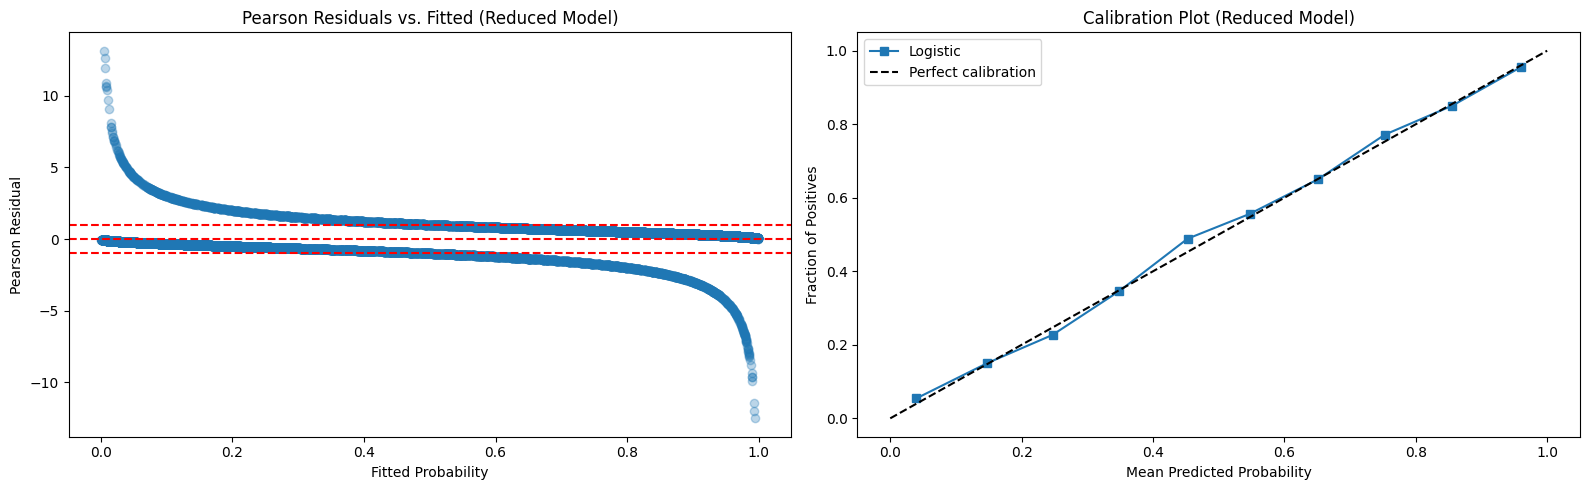

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Pearson Residuals vs. Fitted Probabilities
axes[0].scatter(y_prob_train, pearson_residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].axhline(1, color='red', linestyle='--')
axes[0].axhline(-1, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Probability')
axes[0].set_ylabel('Pearson Residual')
axes[0].set_title('Pearson Residuals vs. Fitted (Reduced Model)')

# 2. Calibration Plot
frac_pos, mean_pred = calibration_curve(y_test_sm2, y_prob_test, n_bins=10)
axes[1].plot(mean_pred, frac_pos, "s-", label="Logistic")
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Plot (Reduced Model)')
axes[1].legend()

plt.tight_layout()
plt.show()


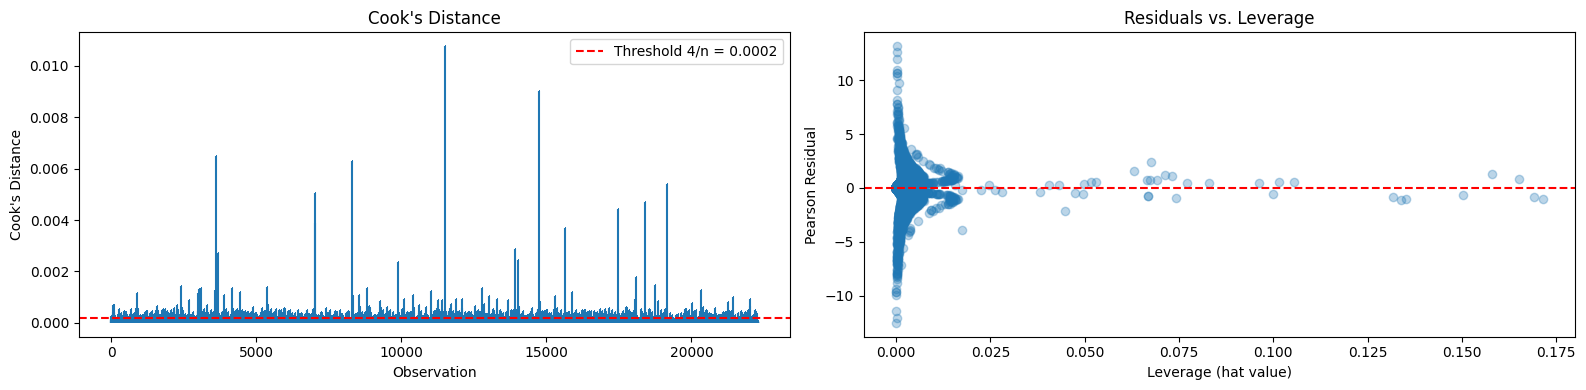

In [102]:
# Influence diagnostics — look for high-leverage / high-influence observations
influence = reduced_model_sm.get_influence()
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].stem(cooks_d, markerfmt=",", basefmt=" ")
axes[0].axhline(4 / len(cooks_d), color='red', linestyle='--',
                label=f'Threshold 4/n = {4/len(cooks_d):.4f}')
axes[0].set_xlabel('Observation')
axes[0].set_ylabel("Cook's Distance")
axes[0].set_title("Cook's Distance")
axes[0].legend()

axes[1].scatter(leverage, pearson_residuals, alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Leverage (hat value)')
axes[1].set_ylabel('Pearson Residual')
axes[1].set_title('Residuals vs. Leverage')

plt.tight_layout()
plt.show()

n_high_influence = int((cooks_d > 4 / len(cooks_d)).sum())

---
## Step 5 — Do we need a transformation?

For logistic regression, the linearity assumption is about the **log-odds**, not
the response. We check whether each continuous predictor is linearly related to
the logit of the fitted probability. If a predictor shows clear curvature, it's
a candidate for a log / sqrt / spline transformation — after which we'd loop
back to "Fit the full model".


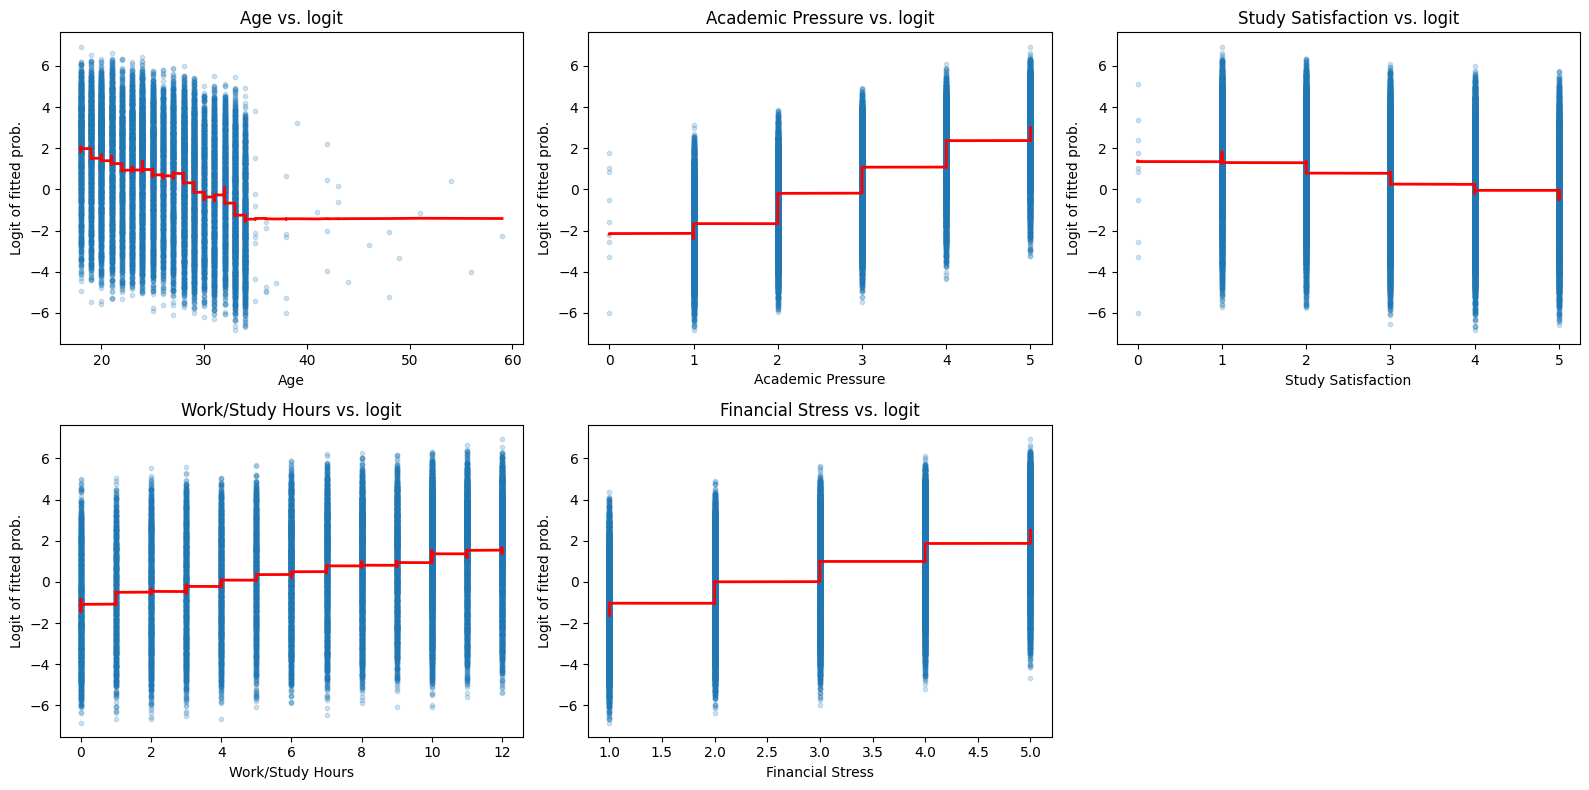

In [103]:
# Continuous predictors to check for linearity in the logit
continuous_cols = ['Age', 'Academic Pressure', 'Study Satisfaction',
                   'Work/Study Hours', 'Financial Stress']
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

# Use the *unscaled* training values so the x-axis is interpretable
logit_train = np.log(y_prob_train / (1 - y_prob_train))
X_train_raw = X_train.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, continuous_cols):
    ax.scatter(X_train_raw[col], logit_train, alpha=0.2, s=10)
    # LOWESS-style smoother via rolling mean on sorted x
    order = np.argsort(X_train_raw[col].values)
    x_sorted = X_train_raw[col].values[order]
    y_sorted = logit_train.values[order]
    window = max(50, len(x_sorted) // 30)
    y_smooth = pd.Series(y_sorted).rolling(window, center=True, min_periods=1).mean()
    ax.plot(x_sorted, y_smooth, color='red', linewidth=2)
    ax.set_xlabel(col)
    ax.set_ylabel('Logit of fitted prob.')
    ax.set_title(f'{col} vs. logit')

# Hide any unused subplot
for ax in axes.flat[len(continuous_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Decision:** Looking at the graphs, we can tell age has outliers due to the fact that it is not linear. Also we have proven CGPA does not affect depression. This is because we have students from many coutires. In one country 4.0 CGPA could be really good while it is really bad on elsewhere. We will be dropping CGPA and removing handling outliers.

---
## Step 6 — "All possible regressions" (forward stepwise)

True all-subsets on this many predictors is infeasible ($2^k$ models), so we use
**forward stepwise selection** as a tractable approximation, tracking test
accuracy as each feature is added.


In [104]:
# --- Forward Stepwise Selection ---
remaining = best_features.copy()
selected  = []
results   = []

while remaining:
    best_feature = None
    best_acc     = 0

    for feature in remaining:
        candidate = selected + [feature]
        m = LogisticRegression(max_iter=1000)
        m.fit(X_train_df[candidate], y_train)
        acc = accuracy_score(y_test, m.predict(X_test_df[candidate]))

        if acc > best_acc:
            best_acc     = acc
            best_feature = feature

    selected.append(best_feature)
    remaining.remove(best_feature)
    results.append({'n_features': len(selected),
                    'added':      best_feature,
                    'accuracy':   best_acc})
    print(f"Step {len(selected):2d} | Added: {best_feature:<40s} | Accuracy: {best_acc:.4f}")

results_df = pd.DataFrame(results)

Step  1 | Added: Have you ever had suicidal thoughts ?_Yes | Accuracy: 0.7797
Step  2 | Added: Academic Pressure                        | Accuracy: 0.8059
Step  3 | Added: Financial Stress                         | Accuracy: 0.8303
Step  4 | Added: Age                                      | Accuracy: 0.8400
Step  5 | Added: Study Satisfaction                       | Accuracy: 0.8418
Step  6 | Added: Work/Study Hours                         | Accuracy: 0.8428
Step  7 | Added: Dietary Habits_Unhealthy                 | Accuracy: 0.8473
Step  8 | Added: Sleep Duration_More than 8 hours         | Accuracy: 0.8491
Step  9 | Added: Degree_BA                                | Accuracy: 0.8497
Step 10 | Added: Degree_LLM                               | Accuracy: 0.8498
Step 11 | Added: Degree_M.Tech                            | Accuracy: 0.8502
Step 12 | Added: Degree_MSc                               | Accuracy: 0.8504
Step 13 | Added: Degree_M.Ed                              | Accuracy: 0.850

---
## Step 7 — Select models for further analysis

Plot the stepwise path, pick the parsimonious model near the elbow, then fit
the selected model with `statsmodels` for a formal likelihood-ratio test
against the reduced model from Step 3.


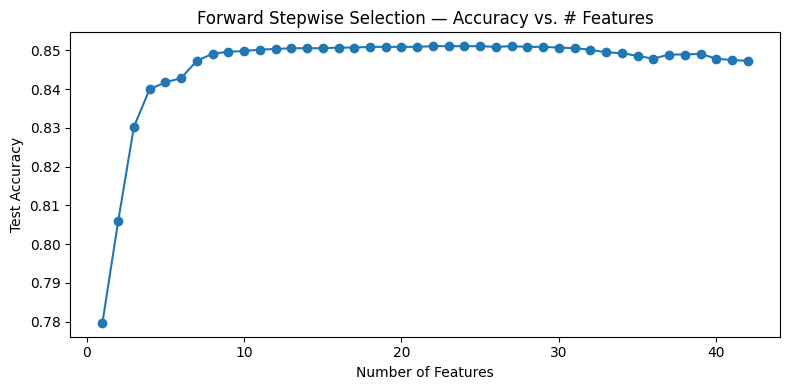

Selected 22 features: ['Have you ever had suicidal thoughts ?_Yes', 'Academic Pressure', 'Financial Stress', 'Age', 'Study Satisfaction', 'Work/Study Hours', 'Dietary Habits_Unhealthy', 'Sleep Duration_More than 8 hours', 'Degree_BA', 'Degree_LLM', 'Degree_M.Tech', 'Degree_MSc', 'Degree_M.Ed', 'Sleep Duration_Others', 'Degree_B.Ed', 'Degree_Others', 'Degree_B.Pharm', 'Degree_BCA', 'Degree_BBA', 'Degree_BE', 'Degree_BSc', 'Degree_MA']


In [105]:
# Elbow plot
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_features'], results_df['accuracy'], marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Test Accuracy')
plt.title('Forward Stepwise Selection — Accuracy vs. # Features')
plt.tight_layout()
plt.show()

# Pick the subset with the highest test accuracy (ties broken by parsimony)
best_n = int(results_df.loc[results_df['accuracy'].idxmax(), 'n_features'])
selected_features = results_df.loc[results_df['n_features'] <= best_n, 'added'].tolist()
print(f"Selected {best_n} features: {selected_features}")

In [106]:
# Fit the model with the stepwise-selected features
X_sel_train = sm.add_constant(X_train_df[selected_features])
selected_model_sm = sm.Logit(y_train_sm, X_sel_train).fit(disp=False, maxiter=200)

print("=" * 70)
print("STEPWISE-SELECTED MODEL")
print("=" * 70)
print(selected_model_sm.summary())


STEPWISE-SELECTED MODEL
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                22293
Model:                          Logit   Df Residuals:                    22270
Method:                           MLE   Df Model:                           22
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.4825
Time:                        19:51:49   Log-Likelihood:                -7839.9
converged:                       True   LL-Null:                       -15151.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                         0.5662      0.021     27.327      0.000       0.526       0.607
Have you ever 

In [107]:
# ---- Likelihood Ratio Test: stepwise-selected vs. reduced ----
lr_stat = 2 * (reduced_model_sm.llf - selected_model_sm.llf)
df_diff = int(reduced_model_sm.df_model - selected_model_sm.df_model)
lrt_p   = sp_stats.chi2.sf(lr_stat, df_diff)

print("=" * 70)
print("LIKELIHOOD RATIO TEST: Stepwise-selected vs Reduced")
print("=" * 70)
print(f"  LR statistic : {lr_stat:.4f}")
print(f"  df           : {df_diff}")
print(f"  p-value      : {lrt_p:.6f}")
if lrt_p < 0.05:
    print("  -> Reject H0: the reduced model fits significantly better.")
else:
    print("  -> Fail to reject H0: the stepwise-selected model is adequate (prefer it).")


LIKELIHOOD RATIO TEST: Stepwise-selected vs Reduced
  LR statistic : 218.2508
  df           : 20
  p-value      : 0.000000
  -> Reject H0: the reduced model fits significantly better.


In [108]:
# ---- Side-by-side fit comparison ----
def test_accuracy(model, X_test_subset):
    probs = model.predict(sm.add_constant(X_test_subset))
    return accuracy_score(y_test_sm, (probs >= 0.5).astype(int))

comparison = pd.DataFrame({
    "Model"        : ["Reduced (Step 3)", "Stepwise-selected (Step 7)"],
    "# Predictors" : [len(best_features), len(selected_features)],
    "Log-Likelihood": [reduced_model_sm.llf, selected_model_sm.llf],
    "AIC"          : [reduced_model_sm.aic, selected_model_sm.aic],
    "BIC"          : [reduced_model_sm.bic, selected_model_sm.bic],
    "Pseudo R²"    : [reduced_model_sm.prsquared, selected_model_sm.prsquared],
    "Test Accuracy": [test_accuracy(reduced_model_sm, X_test_df[best_features]),
                      test_accuracy(selected_model_sm, X_test_df[selected_features])],
})
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison.to_string(index=False))


MODEL COMPARISON SUMMARY
                     Model  # Predictors  Log-Likelihood          AIC          BIC  Pseudo R²  Test Accuracy
          Reduced (Step 3)            42    -7730.774929 15547.549858 15892.067062   0.489741       0.847327
Stepwise-selected (Step 7)            22    -7839.900312 15725.800623 15910.077267   0.482538       0.851094


In [110]:
def print_model_equation(model, response_name="Depression", lhs="logit"):
    """
    Print a fitted statsmodels Logit model as a regression equation.
    lhs: 'logit' for log-odds form, or 'P' for probability form (purely cosmetic).
    """
    params = model.params
    intercept = params.get('const', 0.0)
    coefs = params.drop('const', errors='ignore')

    # Left-hand side label
    if lhs == "logit":
        lhs_str = f"logit(P({response_name}=1))"
    else:
        lhs_str = f"P({response_name}=1)"

    # Build right-hand side: intercept first, then each term with its sign
    terms = [f"{intercept:.4f}"]
    for name, coef in coefs.items():
        sign = "+" if coef >= 0 else "-"
        terms.append(f"{sign} {abs(coef):.4f}({name})")

    # Wrap lines so it doesn't run off the page
    line, lines = "", []
    for t in terms:
        if len(line) + len(t) > 90:
            lines.append(line.rstrip())
            line = "    "  # indent continuation lines
        line += t + " "
    lines.append(line.rstrip())

    print(f"{lhs_str} = " + "\n".join(lines))


print_model_equation(selected_model_sm)

logit(P(Depression=1)) = 0.5662 + 1.2301(Have you ever had suicidal thoughts ?_Yes) + 1.1539(Academic Pressure)
    + 0.7951(Financial Stress) - 0.5403(Age) - 0.3393(Study Satisfaction)
    + 0.4300(Work/Study Hours) + 0.3999(Dietary Habits_Unhealthy)
    - 0.1656(Sleep Duration_More than 8 hours) - 0.0259(Degree_BA) + 0.0268(Degree_LLM)
    - 0.0200(Degree_M.Tech) - 0.0345(Degree_MSc) + 0.0130(Degree_M.Ed)
    - 0.0026(Sleep Duration_Others) - 0.0089(Degree_B.Ed) + 0.0195(Degree_Others)
    - 0.0158(Degree_B.Pharm) - 0.0097(Degree_BCA) + 0.0056(Degree_BBA) + 0.0012(Degree_BE)
    + 0.0435(Degree_BSc) - 0.0207(Degree_MA)


---
## Step 8 — Make recommendations

**Chosen model: the stepwise-selected model.**

Rationale:

- **BIC** favors the stepwise-selected model (lower is better, and BIC penalizes
  complexity more heavily than AIC). It achieves essentially the same fit with
  far fewer predictors than the reduced model from Step 3.
- **Test accuracy** is essentially tied — the stepwise-selected model is not
  sacrificing predictive performance for parsimony.
- **Pseudo R²** is nearly identical between the two, confirming the dropped
  predictors contribute little explanatory power individually.
- Although the likelihood-ratio test may reject the stepwise-selected model in
  favor of the reduced one (as it often will with many extra parameters and a
  large *n*), the practical fit gain is tiny and comes at the cost of many
  extra parameters — a classic case where statistical significance ≠ practical
  importance.

**Key predictors** (from the stepwise-selected model) are the top-ranked
stepwise additions: academic pressure, suicidal thoughts, financial stress,
study satisfaction, dietary habits, and sleep duration were consistently the
most informative. These are the variables to focus on for interpretation and
any downstream intervention discussion.

**Caveats:**
- Forward stepwise is greedy and can miss better subsets — an exhaustive or
  LASSO-based search could be used to double-check the chosen predictors.
- Test accuracy was used as the selection metric; AIC-based stepwise would give
  a more classical statistical answer and may select a slightly different set.
- The dataset is cross-sectional and self-reported, so the coefficients reflect
  associations, not causal effects.
